# Local Twist Analysis

In [42]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import cyltransf as ct

file_dir = "data100ns-2008"
output_dir = "output"

u_mean = md.Universe(file_dir + "/md_1.tpr", output_dir + "/md_1_mean.xtc")
chains = u_mean.select_atoms("protein").fragments

# "Nematic" Configuration - For Testing
u_start = md.Universe(file_dir + "/md_1.tpr", file_dir + "/md_1_noPBC.xtc")
u_start.trajectory[0] # Make Analysis of Starting Frame - Nematic
chains_start = u_start.select_atoms("protein").fragments

# COM for centering - Starting Position
com = u_start.select_atoms("protein").center_of_mass() / 10
com_start = np.array([com[0], com[1], 0.0])

In [43]:
mol = 0

In [44]:
# By Chains as we want the local twist
# Mean Data of the Molecule, we are not using cylindrical proj now
molchs_m = [[],[],[]]
molch = chains_start[3*mol:3*mol + 3]
for i in range(3):
    molchs_m[i] = molch[i].positions / 10
    molchs_m[i] = ct.remove_ends(0.5, molchs_m[i])

# Start Data
molchs_i = [[],[],[]]
molch = chains_start[3*mol:3*mol + 3]
for i in range(3):
    molchs_i[i] = molch[i].positions / 10 - com_start
    molchs_i[i] = ct.remove_ends(0.5, molchs_i[i])

Starting Position

In [52]:
psi_ch =[[],[],[]]
for i in range(3):
    x, y, z = [molchs_i[i][:, j] for j in range(3)]
    atoms_pairs = len(x) - 1
    psis = np.zeros(atoms_pairs)
    for a in range(atoms_pairs): # By pairs (consecutive)
        # Get line slope - slope as the change between local r displacement and z (dz/dr)
        dx = x[a+1] - x[a]
        dy = y[a+1] - y[a]
        dz = z[a+1] - z[a]
        dr = np.sqrt(dy**2 + dx**2)
        psis[a] = np.rad2deg(np.atan(abs(dr/dz))) # angle = arctan(co/ca) = arctan(tan(angle)) - we add the absolute given posible negative slope, we dont care
    psi_ch[i] = psis

/var/folders/mh/rthhjqxd0q17zgrqn8510w6h0000gn/T/ipykernel_3357/944324689.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  psis[a] = np.rad2deg(np.atan(abs(dr/dz))) # angle = arctan(co/ca) = arctan(tan(angle)) - we add the absolute given posible negative slope, we dont care


Vis Starting Position

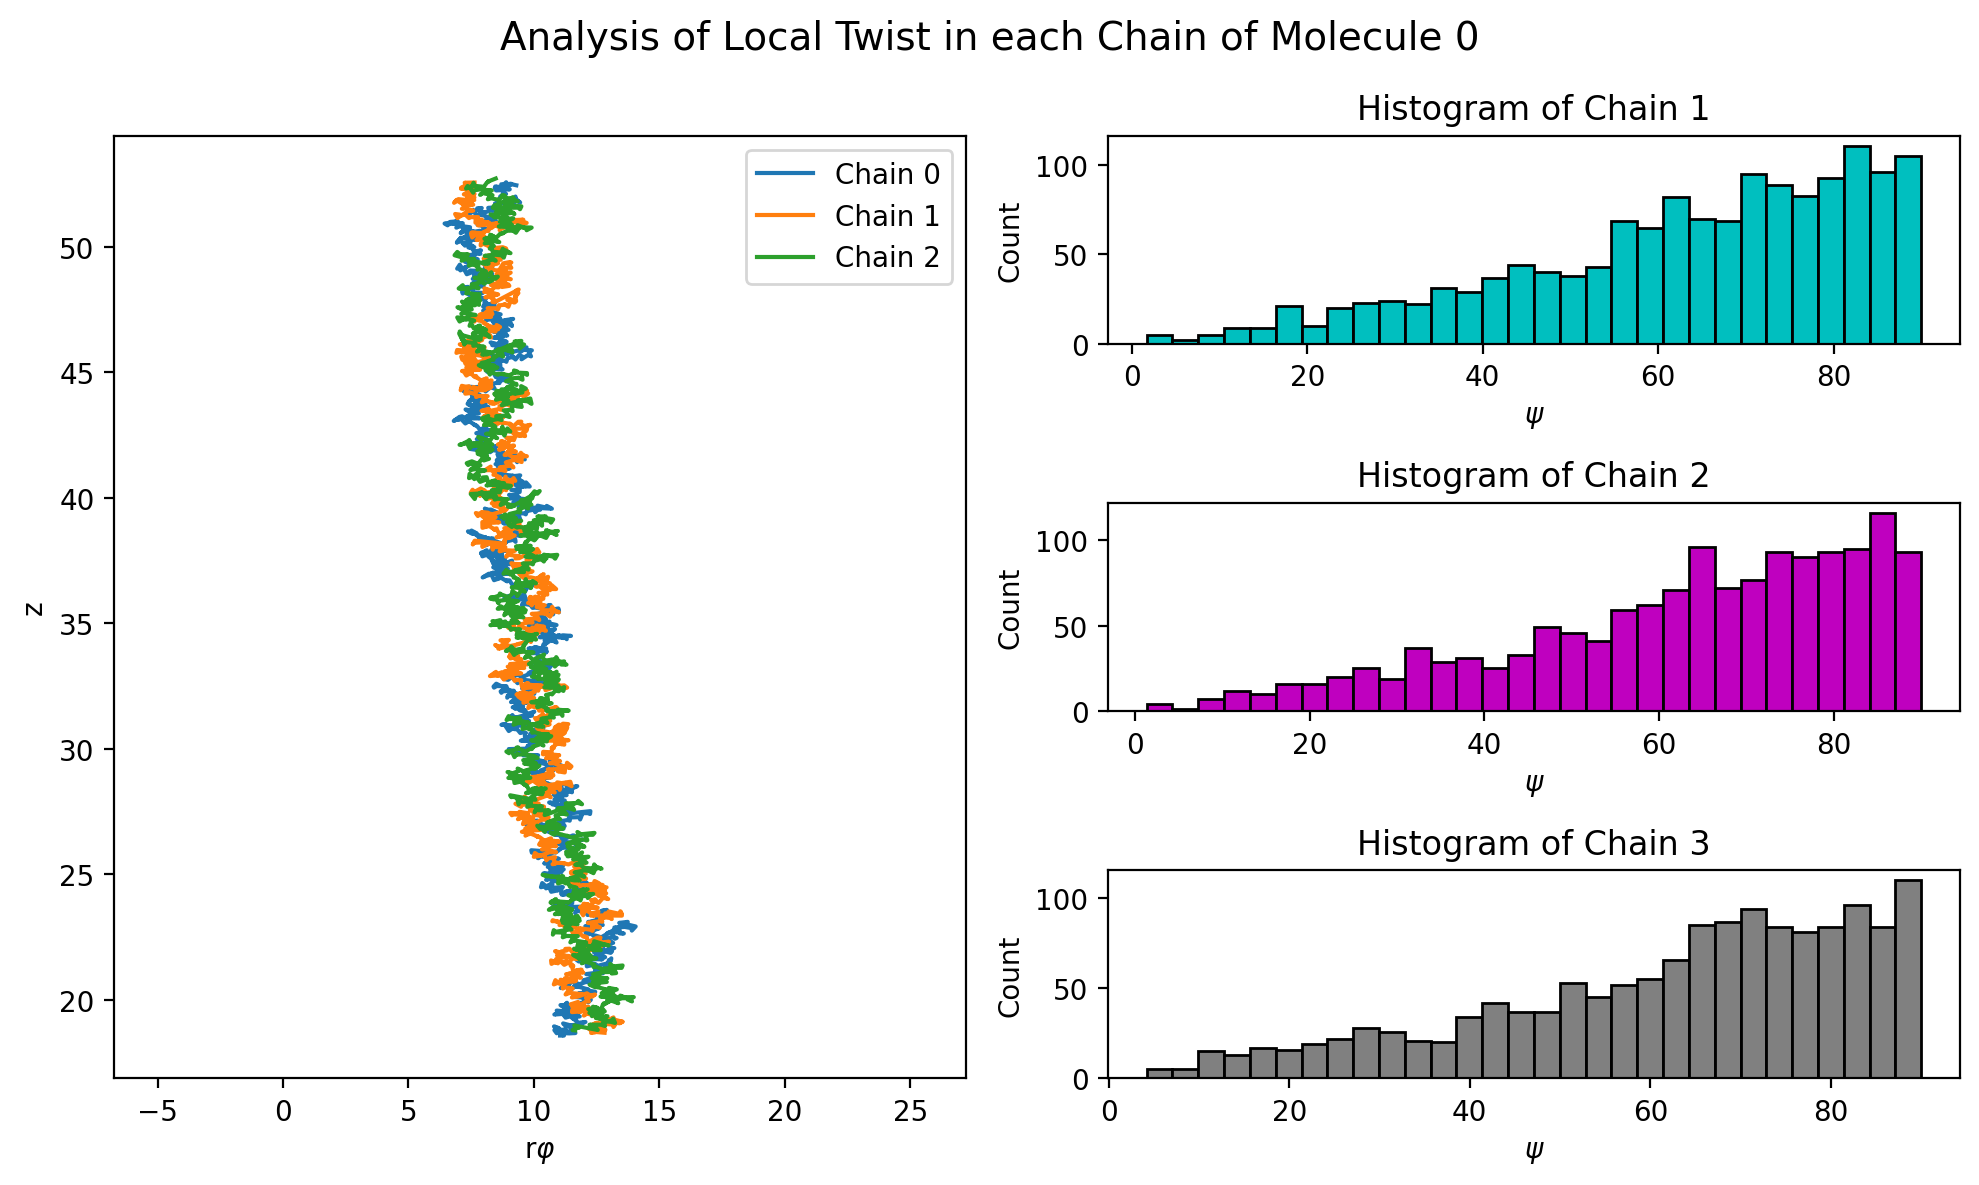

In [53]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 6), dpi=200)
gs = GridSpec(3, 2, figure=fig)  # 3 rows, 2 columns

# --- Phi vs Z --- 
ax0 = fig.add_subplot(gs[:, 0])
for i in range(3):
    r, phi, z = ct.cyl_proj(molchs_i[i])
    arc = r*phi
    ax0.plot(arc, z, label=f"Chain {i}")
ax0.axis('equal')
ax0.set_xlabel(r'r$\varphi$')
ax0.set_ylabel(r'z')
ax0.legend()

# --- Local Psis Calculated ---
# --- Chain 1 ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(psi_ch[0], bins=30, color='c', edgecolor='k')
ax2.set_xlabel(r'$\psi$')
ax2.set_ylabel('Count')
ax2.set_title('Histogram of Chain 1')

# --- Chain 2 ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(psi_ch[1], bins=30, color='m', edgecolor='k')
ax3.set_xlabel(r'$\psi$')
ax3.set_ylabel('Count')
ax3.set_title('Histogram of Chain 2')

# --- Chain 2 ---
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(psi_ch[2], bins=30, color='grey', edgecolor='k')
ax4.set_xlabel(r'$\psi$')
ax4.set_ylabel('Count')
ax4.set_title('Histogram of Chain 3')

plt.suptitle(rf'Analysis of Local Twist in each Chain of Molecule {mol}', fontsize=14)
plt.tight_layout()
plt.show()